# Acoplamento vento solar-magnetosfera (notebook corrigido v2)

IC — astrofísica computacional. Pipeline: ingestão OMNI -> tratamento de gaps -> funções de acoplamento (Akasofu ε e Newell et al., corrigidas) -> solver da equação de Burton et al. (1975) -> calibração global (differential_evolution) -> comparação contra o Dst observado na tempestade de Gannon (10-12/mai/2024).

Este notebook consolida TODAS as correções já validadas:
- Contorno do bloqueio do Smart App Control no `netCDF4` (stub, não afeta a ingestão OMNI)
- `clock_angle` com `arccos` + `clip` (evita NaN em potências fracionárias)
- Solver RK4 de passo fixo (rápido, substitui `solve_ivp`)
- Calibração com janela restrita à tempestade (evita diluição do sinal)
- Calibração global via `differential_evolution` (evita mínimos locais degenerados do Nelder-Mead)


In [1]:
# Contorna o bloqueio do Smart App Control (Windows): o netCDF4 não é
# necessário para a ingestão OMNI, só para um exportador do pyspedas que
# não usamos aqui. Se o import real falhar, usamos um stub.
import sys
import types

if "netCDF4" not in sys.modules:
    try:
        import netCDF4  # tenta o real primeiro, caso já funcione
    except ImportError:
        fake_netcdf4 = types.ModuleType("netCDF4")

        class _DatasetIndisponivel:
            def __init__(self, *args, **kwargs):
                raise RuntimeError(
                    "netCDF4 bloqueado pelo Smart App Control e não é "
                    "necessário para a ingestão OMNI deste projeto."
                )

        fake_netcdf4.Dataset = _DatasetIndisponivel
        fake_netcdf4.num2date = lambda *a, **k: None
        sys.modules["netCDF4"] = fake_netcdf4
        print("Aviso: netCDF4 real indisponível — usando stub (ok para este projeto).")


In [2]:
import pyspedas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## 1. Ingestão de dados OMNI

Baixa dados de 1 minuto do vento solar/IMF (By, Bz, V) e do índice Dst para a janela da
tempestade de Gannon (10-12 de maio de 2024), direto do banco OMNI (NASA/GSFC SPDF).


In [3]:
trange = ['2024-05-10', '2024-05-12']

var_names = pyspedas.omni.data(
    trange=trange,
    datatype='1min',
    time_clip=True,
)
print(var_names)


06-Oct-26 21:44:34: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/omni/omni_cdaweb/hro_1min/2024/
06-Oct-26 21:44:36: File is current: omni_data/hro_1min/2024/omni_hro_1min_20240501_v01.cdf


['IMF', 'PLS', 'IMF_PTS', 'PLS_PTS', 'percent_interp', 'Timeshift', 'RMS_Timeshift', 'RMS_phase', 'Time_btwn_obs', 'F', 'BX_GSE', 'BY_GSE', 'BZ_GSE', 'BY_GSM', 'BZ_GSM', 'RMS_SD_B', 'RMS_SD_fld_vec', 'flow_speed', 'Vx', 'Vy', 'Vz', 'proton_density', 'T', 'Pressure', 'E', 'Beta', 'Mach_num', 'Mgs_mach_num', 'x', 'y', 'z', 'BSN_x', 'BSN_y', 'BSN_z', 'AE_INDEX', 'AL_INDEX', 'AU_INDEX', 'SYM_D', 'SYM_H', 'ASY_D', 'ASY_H', 'PC_N_INDEX']


## 2. Conversão para DataFrame

Extrai as séries temporais relevantes (By GSM, Bz GSM, velocidade do vento solar, Dst)
das tplot variables e monta um `DataFrame` único indexado por tempo.


In [4]:
from pyspedas.tplot_tools import get_data

def tvar_to_series(nome):
    dados = get_data(nome)
    tempo = pd.to_datetime(dados.times, unit='s')
    valores = np.asarray(dados.y, dtype=float)
    return pd.Series(valores, index=tempo)

by = tvar_to_series('BY_GSM')
bz = tvar_to_series('BZ_GSM')
v = tvar_to_series('flow_speed')
dst = tvar_to_series('SYM_H') if 'SYM_H' in var_names else tvar_to_series('DST1800')

df = pd.DataFrame({'By': by, 'Bz': bz, 'V': v, 'Dst': dst}).sort_index()
df = df[~df.index.duplicated(keep='first')]
df.head()


,By,Bz,V,Dst
2024-05-10 00:00:00,NaN,NaN,NaN,6.0
2024-05-10 00:01:00,NaN,NaN,NaN,6.0
2024-05-10 00:02:00,NaN,NaN,NaN,6.0
2024-05-10 00:03:00,NaN,NaN,NaN,6.0
2024-05-10 00:04:00,NaN,NaN,NaN,6.0


## 3. Detecção e tratamento de gaps

Pequenos gaps (<=10 min) são interpolados linearmente. Gaps grandes (ex.: saturação de
instrumento durante a tempestade) são mascarados, não interpolados — não fabricamos dado
onde não existe medição confiável.


In [5]:
def contar_gaps(serie, freq='1min'):
    idx_completo = pd.date_range(serie.index.min(), serie.index.max(), freq=freq)
    faltantes = idx_completo.difference(serie.index).union(serie[serie.isna()].index)
    return sorted(set(faltantes))

gaps_bz = contar_gaps(df['Bz'].dropna())
print(f"Timestamps faltantes/NaN em Bz: {len(gaps_bz)}")


Timestamps faltantes/NaN em Bz: 180


In [6]:
# Interpola gaps curtos (<=10 pontos consecutivos = 10 min a 1 min de resolução)
df_interp = df.copy()
for col in ['By', 'Bz', 'V']:
    df_interp[col] = df_interp[col].interpolate(method='linear', limit=10, limit_area='inside')

# Máscara de validade: True onde o dado é confiável (original ou interpolado em gap curto)
mascara_valida = df_interp[['By', 'Bz', 'V']].notna().all(axis=1)
print(f"Pontos válidos após tratamento: {mascara_valida.sum()} / {len(df_interp)}")

df = df_interp


Pontos válidos após tratamento: 2284 / 2881


In [7]:
# Preenche NaNs remanescentes (bordas da série, gaps grandes mascarados) —
# necessário para o solver não quebrar. A confiabilidade desses trechos
# continua registrada em mascara_valida, caso precise filtrar depois.
for col in ['By', 'Bz', 'V', 'Dst']:
    n_nan = df[col].isna().sum()
    if n_nan:
        print(f"{col}: {n_nan} NaN restantes — preenchendo (forward/backward fill)")
    df[col] = df[col].ffill().bfill()

print(f"NaN restantes no df: {df[['By','Bz','V','Dst']].isna().sum().sum()}")

By: 491 NaN restantes — preenchendo (forward/backward fill)
Bz: 491 NaN restantes — preenchendo (forward/backward fill)
V: 595 NaN restantes — preenchendo (forward/backward fill)
NaN restantes no df: 0


## 4. Checagem visual (Bz e Dst)

Inspeção visual rápida: Bz deve ficar fortemente negativo durante a fase principal da
tempestade, coincidindo com a maior queda do Dst.


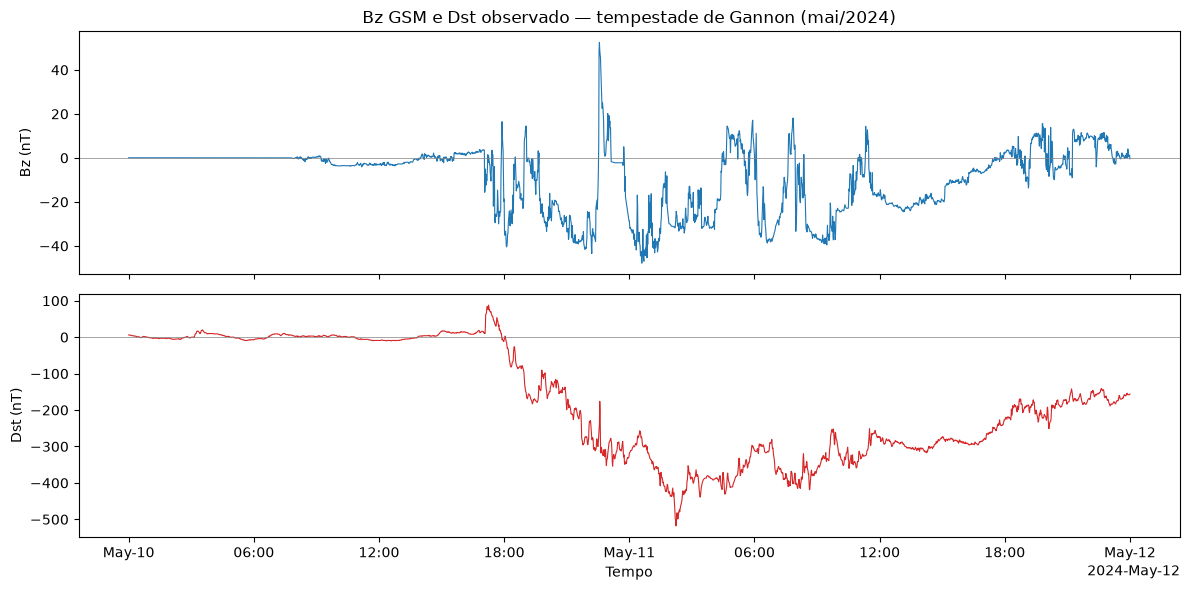

In [8]:
fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axs[0].plot(df.index, df['Bz'], color='tab:blue', linewidth=0.8)
axs[0].axhline(0, color='gray', linewidth=0.5)
axs[0].set_ylabel('Bz (nT)')
axs[0].set_title('Bz GSM e Dst observado — tempestade de Gannon (mai/2024)')

axs[1].plot(df.index, df['Dst'], color='tab:red', linewidth=0.8)
axs[1].axhline(0, color='gray', linewidth=0.5)
axs[1].set_ylabel('Dst (nT)')
axs[1].set_xlabel('Tempo')

plt.tight_layout()
plt.show()


## 5. Funções de acoplamento — CORRIGIDAS

`clock_angle` usa `arccos` (não-sinalizado, sempre em [0, pi]) em vez de `arctan2`
(sinalizado), e faz `clip` do argumento para evitar `NaN` por estouro de ponto flutuante.
Isso é essencial para o Newell et al., que usa expoente fracionário (8/3): uma base
negativa elevada a uma potência fracionária gera `NaN` em `numpy`.


In [9]:
def clock_angle(by, bz):
    """Ângulo de clock, sempre entre 0 e pi (não-sinalizado) — evita base negativa
    em potências fracionárias (o Newell usa expoente 8/3)."""
    Bt = np.sqrt(by**2 + bz**2)
    with np.errstate(invalid='ignore', divide='ignore'):
        ratio = np.where(Bt > 0, bz / Bt, 1.0)
    ratio = np.clip(ratio, -1.0, 1.0)
    return np.arccos(ratio)


def akasofu_epsilon(v, by, bz):
    Bt = np.sqrt(by**2 + bz**2)
    theta_c = clock_angle(by, bz)
    return v * Bt**2 * np.sin(theta_c / 2)**4


def newell_coupling(v, by, bz):
    Bt = np.sqrt(by**2 + bz**2)
    theta_c = clock_angle(by, bz)
    return (v**(4/3)) * (Bt**(2/3)) * np.sin(theta_c / 2)**(8/3)


In [10]:
Q_akasofu_arr = akasofu_epsilon(df['V'].values, df['By'].values, df['Bz'].values)
Q_newell_arr = newell_coupling(df['V'].values, df['By'].values, df['Bz'].values)

print(f"NaN em Q_akasofu_arr: {np.isnan(Q_akasofu_arr).sum()}")
print(f"NaN em Q_newell_arr: {np.isnan(Q_newell_arr).sum()}")


NaN em Q_akasofu_arr: 0
NaN em Q_newell_arr: 0


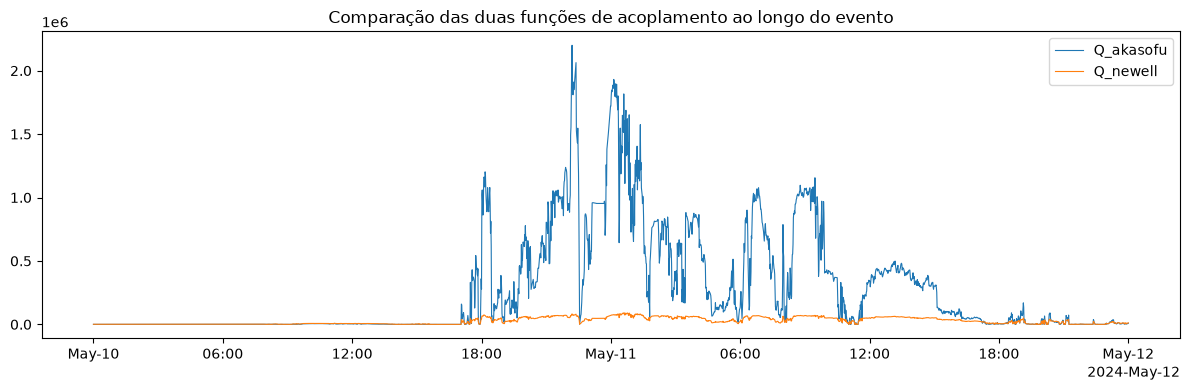

In [11]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.index, Q_akasofu_arr, label='Q_akasofu', linewidth=0.8)
ax.plot(df.index, Q_newell_arr, label='Q_newell', linewidth=0.8)
ax.set_title('Comparação das duas funções de acoplamento ao longo do evento')
ax.legend()
plt.tight_layout()
plt.show()


## 6. Solver — RK4 passo fixo

Integrador de passo fixo, casado com a cadência nativa dos dados (1 min). Muito mais
rápido que `scipy.integrate.solve_ivp` para uso dentro de um laço de otimização.


In [12]:
def simular_burton_rk4(Q_array, dst0, tau, escala, dt=60.0):
    n = len(Q_array)
    dst = np.empty(n)
    dst[0] = dst0
    for i in range(n - 1):
        Qi = -Q_array[i] * escala
        Qi1 = -Q_array[i + 1] * escala
        y = dst[i]
        k1 = Qi - y / tau
        k2 = Qi - (y + 0.5 * dt * k1) / tau
        k3 = Qi - (y + 0.5 * dt * k2) / tau
        k4 = Qi1 - (y + dt * k3) / tau
        dst[i + 1] = y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)
    return dst


dt = 60.0
dst0 = df['Dst'].iloc[0]

## 7. Janela de calibração

Restringe o cálculo do erro (RMSE) à fase ativa da tempestade, evitando que o longo
trecho calmo antes/depois dilua o sinal e puxe a calibração para uma solução trivial
(escala quase zero).


In [13]:
inicio_tempestade = pd.Timestamp('2024-05-10 16:00')
fim_tempestade = pd.Timestamp('2024-05-11 12:00')
mask_tempestade = (df.index >= inicio_tempestade) & (df.index <= fim_tempestade)

print(f"Pontos na janela de calibração: {mask_tempestade.sum()}")


Pontos na janela de calibração: 1201


In [14]:
def erro_rmse_rk4(log_params, Q_array, dst0, dst_obs, mask):
    log_tau, log_escala = log_params
    tau = 10 ** log_tau
    escala = 10 ** log_escala
    sim = simular_burton_rk4(Q_array, dst0, tau, escala, dt)
    return np.sqrt(np.mean((sim[mask] - dst_obs[mask]) ** 2))


bounds_log = [(np.log10(3600), np.log10(8 * 3600)), (-12, -2)]


## 8. Calibração — busca global (differential_evolution)

Nelder-Mead (local) convergia repetidamente para um mínimo degenerado (`escala` ≈ 0,
"não fazer nada"), com RMSE idêntico entre Akasofu e Newell. `differential_evolution`
varre todo o espaço de busca em vez de descer a partir de um único ponto.


In [15]:
from scipy.optimize import differential_evolution

def calibrar_global(func_coupling, Q_array, dst0, dst_obs, mask, dt, bounds_log, seed=42):
    resultado = differential_evolution(
        erro_rmse_rk4,
        bounds=bounds_log,
        args=(Q_array, dst0, dst_obs, mask),
        seed=seed,
        maxiter=200,
        tol=1e-8,
        polish=True,
        workers=1,
    )
    log_tau, log_escala = resultado.x
    tau = 10 ** log_tau
    escala = 10 ** log_escala
    return tau, escala, resultado.fun


tau_akasofu, escala_akasofu, rmse_akasofu = calibrar_global(
    akasofu_epsilon, Q_akasofu_arr, dst0, df['Dst'].values, mask_tempestade, dt, bounds_log
)
print(f"Akasofu — tau (s): {tau_akasofu:.1f} | escala: {escala_akasofu:.3e} | RMSE: {rmse_akasofu:.4f}")

tau_newell, escala_newell, rmse_newell = calibrar_global(
    newell_coupling, Q_newell_arr, dst0, df['Dst'].values, mask_tempestade, dt, bounds_log
)
print(f"Newell — tau (s): {tau_newell:.1f} | escala: {escala_newell:.3e} | RMSE: {rmse_newell:.4f}")

Akasofu — tau (s): 18736.8 | escala: 3.108e-08 | RMSE: 49.4148
Newell — tau (s): 13885.4 | escala: 5.233e-07 | RMSE: 41.0253


## 9. Resultado final — Dst simulado vs observado


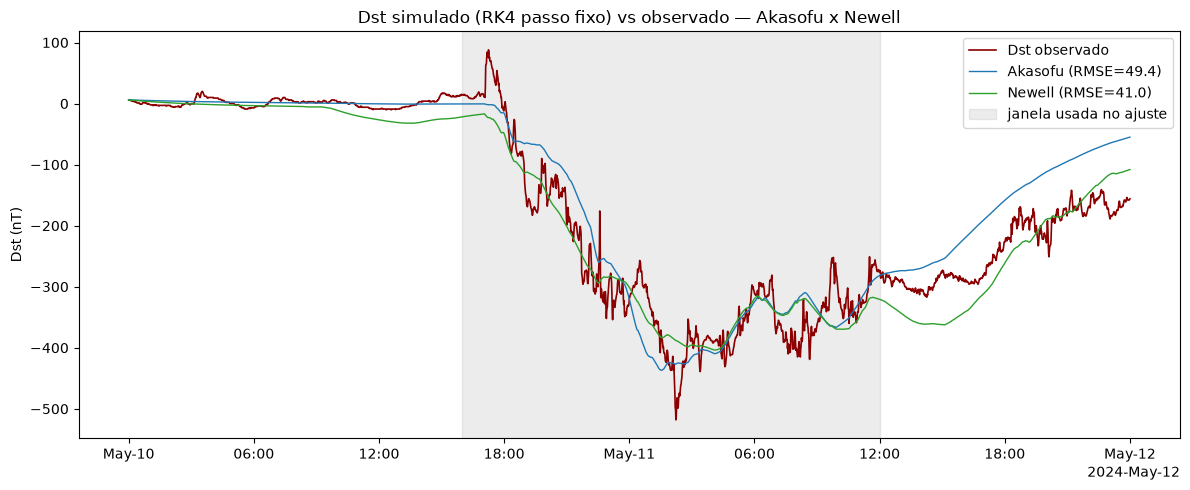


=== Resumo da calibração ===
Akasofu : tau=18736.8s  escala=3.108e-08  RMSE=49.4148
Newell  : tau=13885.4s  escala=5.233e-07  RMSE=41.0253
Melhor ajuste (menor RMSE): Newell


In [16]:
sim_akasofu = simular_burton_rk4(Q_akasofu_arr, dst0, tau_akasofu, escala_akasofu, dt)
sim_newell = simular_burton_rk4(Q_newell_arr, dst0, tau_newell, escala_newell, dt)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df.index, df['Dst'], label='Dst observado', color='darkred', linewidth=1.2)
ax.plot(df.index, sim_akasofu, label=f'Akasofu (RMSE={rmse_akasofu:.1f})', color='tab:blue', linewidth=1.0)
ax.plot(df.index, sim_newell, label=f'Newell (RMSE={rmse_newell:.1f})', color='tab:green', linewidth=1.0)
ax.axvspan(inicio_tempestade, fim_tempestade, color='gray', alpha=0.15, label='janela usada no ajuste')
ax.set_ylabel('Dst (nT)')
ax.set_title('Dst simulado (RK4 passo fixo) vs observado — Akasofu x Newell')
ax.legend()
plt.tight_layout()
plt.show()

print()
print("=== Resumo da calibração ===")
print(f"Akasofu : tau={tau_akasofu:.1f}s  escala={escala_akasofu:.3e}  RMSE={rmse_akasofu:.4f}")
print(f"Newell  : tau={tau_newell:.1f}s  escala={escala_newell:.3e}  RMSE={rmse_newell:.4f}")
melhor = "Akasofu" if rmse_akasofu < rmse_newell else "Newell"
print(f"Melhor ajuste (menor RMSE): {melhor}")


## 10. Validação cruzada — segunda tempestade (St. Patrick's Day, mar/2015)

Um único evento (Gannon) não prova que Newell é consistentemente melhor que Akasofu —
pode ser coincidência daquele evento específico. Para fortalecer a conclusão, roda-se o
mesmo pipeline (ingestão, tratamento de gaps, acoplamento, calibração) numa segunda
tempestade forte e independente: St. Patrick's Day (17-18 de março de 2015, Dst mínimo
~-223 nT).

Primeiro, encapsula-se tudo que já foi feito manualmente para Gannon numa função
reutilizável.


In [17]:
from ingestao import rodar_pipeline_tempestade

# Reaplica no próprio evento de Gannon, por consistência (reusa os mesmos nomes de variável)
resultado_gannon = {
    'nome': 'Gannon (mai/2024)',
    'tau_akasofu': tau_akasofu, 'escala_akasofu': escala_akasofu, 'rmse_akasofu': rmse_akasofu,
    'tau_newell': tau_newell, 'escala_newell': escala_newell, 'rmse_newell': rmse_newell,
}

ModuleNotFoundError: No module named 'ingestao'

In [ ]:
resultado_stpatrick = rodar_pipeline_tempestade(
    nome_evento="St. Patrick's Day (mar/2015)",
    trange=['2015-03-17', '2015-03-19'],
    inicio_tempestade=pd.Timestamp('2015-03-17 04:00'),
    fim_tempestade=pd.Timestamp('2015-03-18 00:00'),
)

06-Oct-26 21:00:20: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/omni/omni_cdaweb/hro_1min/2015/


=== St. Patrick's Day (mar/2015) ===


06-Oct-26 21:00:23: Downloading https://spdf.gsfc.nasa.gov/pub/data/omni/omni_cdaweb/hro_1min/2015/omni_hro_1min_20150301_v01.cdf to omni_data/hro_1min/2015/omni_hro_1min_20150301_v01.cdf
06-Oct-26 21:00:36: Download of omni_data/hro_1min/2015/omni_hro_1min_20150301_v01.cdf complete, 8.366 MB in 13.8 sec (0.607 MB/sec) (transfer_slow)
06-Oct-26 21:00:38: c:\Users\gsava\Documents\projetos\study\GeracaoMartece-IC\core\.venv\Lib\site-packages\cdflib\epochs.py:180: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  total_datetime = np.array(sum(arrays))

06-Oct-26 21:00:38: c:\Users\gsava\Documents\projetos\study\GeracaoMartece-IC\core\.venv\Lib\site-packages\cdflib\epochs.py:181: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of

Akasofu : tau=28800.0s  escala=4.431e-08  RMSE=25.2955
Newell  : tau=28800.0s  escala=2.757e-07  RMSE=21.7787



In [ ]:
print("=== Comparação entre eventos ===")
for r in [resultado_gannon, resultado_stpatrick]:
    melhor = "Newell" if r['rmse_newell'] < r['rmse_akasofu'] else "Akasofu"
    diferenca_pct = abs(r['rmse_akasofu'] - r['rmse_newell']) / max(r['rmse_akasofu'], r['rmse_newell']) * 100
    print(f"{r['nome']:<22} | Akasofu RMSE={r['rmse_akasofu']:.2f} | Newell RMSE={r['rmse_newell']:.2f} | melhor: {melhor} ({diferenca_pct:.1f}% menor)")

=== Comparação entre eventos ===
Gannon (mai/2024)      | Akasofu RMSE=49.41 | Newell RMSE=41.03 | melhor: Newell (17.0% menor)
St. Patrick's Day (mar/2015) | Akasofu RMSE=25.30 | Newell RMSE=21.78 | melhor: Newell (13.9% menor)


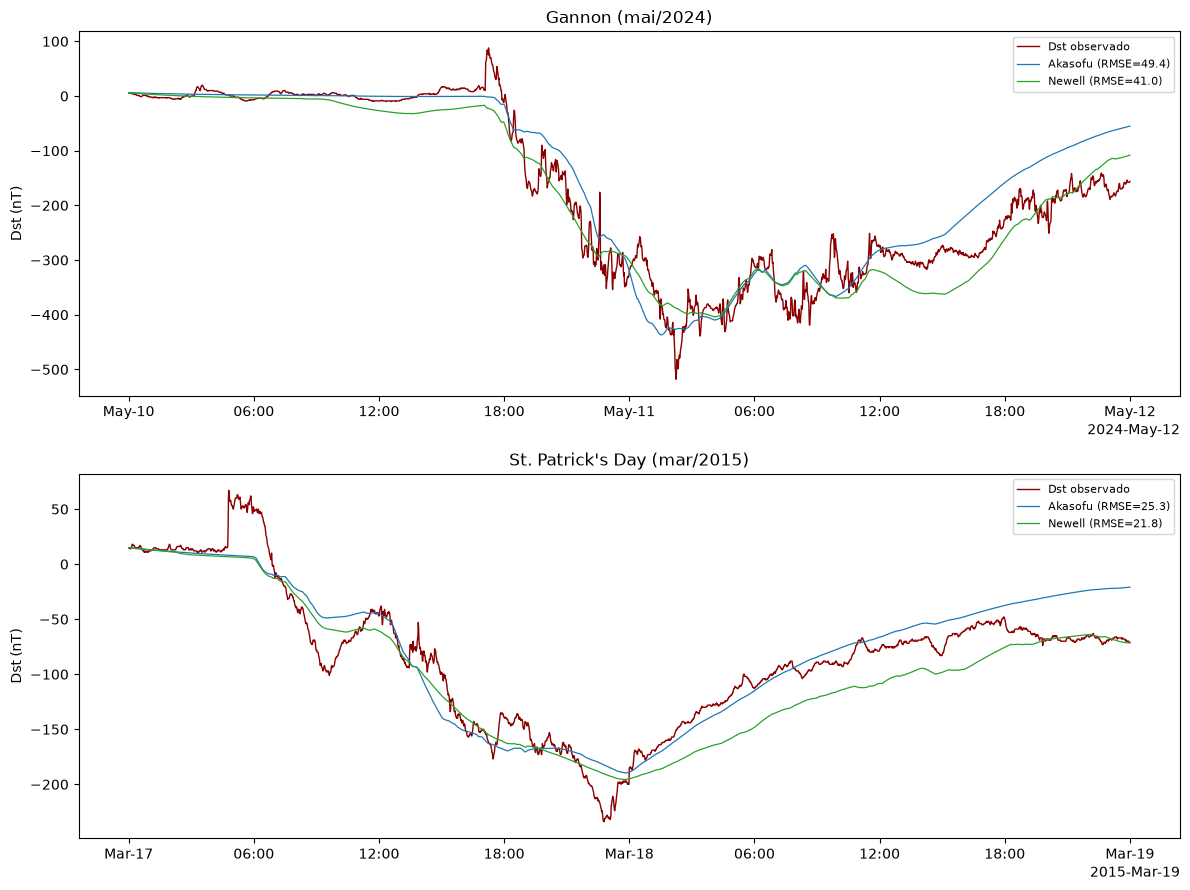

In [ ]:
def plotar_comparacao_evento(ax, resultado, Q_akasofu_evt, Q_newell_evt, dst0_evt, dt_evt):
    df_evt = resultado['df']
    sim_ak = simular_burton_rk4(Q_akasofu_evt, dst0_evt, resultado['tau_akasofu'], resultado['escala_akasofu'], dt_evt)
    sim_nw = simular_burton_rk4(Q_newell_evt, dst0_evt, resultado['tau_newell'], resultado['escala_newell'], dt_evt)
    ax.plot(df_evt.index, df_evt['Dst'], label='Dst observado', color='darkred', linewidth=1.0)
    ax.plot(df_evt.index, sim_ak, label=f"Akasofu (RMSE={resultado['rmse_akasofu']:.1f})", color='tab:blue', linewidth=0.9)
    ax.plot(df_evt.index, sim_nw, label=f"Newell (RMSE={resultado['rmse_newell']:.1f})", color='tab:green', linewidth=0.9)
    ax.set_title(resultado['nome'])
    ax.set_ylabel('Dst (nT)')
    ax.legend(fontsize=8)


fig, axs = plt.subplots(2, 1, figsize=(12, 9))

# Gannon usa as variáveis já calculadas no corpo principal do notebook
resultado_gannon['df'] = df
plotar_comparacao_evento(axs[0], resultado_gannon, Q_akasofu_arr, Q_newell_arr, dst0, dt)

# St. Patrick's Day: recalcula Q a partir do df que já está salvo no resultado
df_sp = resultado_stpatrick['df']
Q_ak_sp = akasofu_epsilon(df_sp['V'].values, df_sp['By'].values, df_sp['Bz'].values)
Q_nw_sp = newell_coupling(df_sp['V'].values, df_sp['By'].values, df_sp['Bz'].values)
dst0_sp = df_sp['Dst'].iloc[0]
plotar_comparacao_evento(axs[1], resultado_stpatrick, Q_ak_sp, Q_nw_sp, dst0_sp, dt)

plt.tight_layout()
plt.show()